In [12]:
import os, re, math
from pathlib import Path
from datetime import datetime

import dotenv, yaml
dotenv.load_dotenv("configs/local.env")


def model_cache_path(model_id):
    home_dir = Path.home()
    cache_dir = os.environ.get('HF_HUB_CACHE',  home_dir / ".cache" / "huggingface" / "hub")

    model_hf = Path(cache_dir) / ("models--" + model_id.replace("/", "--"))
    model_ref = (model_hf / "refs" / "main").read_text(encoding="utf-8").strip()
    model_path = model_hf / "snapshots" / model_ref

    return model_path

In [13]:
import matplotlib.pyplot as plt

from tqdm import tqdm
import torch
import torch.nn.functional as F
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed
from datasets import load_dataset, Dataset, DatasetDict
from peft import PeftModel

In [14]:
# Constants
#BASE_MODEL = "meta-llama/Meta-Llama-3.1-8B"
BASE_MODEL = "meta-llama/Llama-3.2-1B"
PROJECT_NAME = "pricer"
HF_USER = "ed-donner" # your HF name here! Or use mine if you just want to reproduce my results.

# The run itself
RUN_NAME = "2024-09-13_13.04.39"
PROJECT_RUN_NAME = f"{PROJECT_NAME}-{RUN_NAME}"
REVISION = "e8d637df551603dc86cd7a1598a8f44af4d7ae36" # or REVISION = None
FINETUNED_MODEL = f"{HF_USER}/{PROJECT_RUN_NAME}"

# Uncomment this line if you wish to use my model
# FINETUNED_MODEL = f"ed-donner/{PROJECT_RUN_NAME}"

# Data
DATASET_NAME = f"{HF_USER}/pricer-data"
# Or just use the one I've uploaded
# DATASET_NAME = "ed-donner/pricer-data"

# Used for writing to output in color
COLOR_MAP = {"red": "\033[91m", "orange": "\033[93m", "green": "\033[92m", 'rest': "\033[0m"}

In [15]:
# Optonal: offline mode

os.environ['HF_HUB_OFFLINE'] = 'True'
os.environ['WANDB_MODE'] = 'offline'
BASE_MODEL = model_cache_path(BASE_MODEL)
FINETUNED_MODEL = "data/pricer-2025-08-11"

#checkpoints = sorted(
#    Path(FINETUNED_MODEL).glob("checkpoint-*/"),
#    key=lambda x: x.stat().st_ctime,
#    #key=lambda x: int(x.name.split("-")[1]),
#    reverse=True,
#)
#if len(checkpoints) > 0:
#    FINETUNED_MODEL = checkpoints[0]

#print(f"--> FINETUNED_MODEL: {FINETUNED_MODEL}")

In [16]:
dataset = load_dataset(DATASET_NAME)
train = dataset['train']
test = dataset['test']

Using the latest cached version of the dataset since ed-donner/pricer-data couldn't be found on the Hugging Face Hub (offline mode is enabled).
Found the latest cached dataset configuration 'default' at data/huggingface/datasets/ed-donner___pricer-data/default/0.0.0/f38df5f756eafe7e331348b26a823e4d706f4a08 (last modified on Tue Aug 12 23:37:21 2025).


In [17]:
# pick the right quantization (thank you Robert M. for spotting the bug with the 8 bit version!)

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4",
)
# quant_config = BitsAndBytesConfig(load_in_8bit=True, bnb_8bit_compute_dtype=torch.bfloat16)

In [18]:
# Load the Tokenizer and the Model
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
)
base_model.generation_config.pad_token_id = tokenizer.pad_token_id
print(f"Memory footprint: {base_model.get_memory_footprint() / 1e6:.1f} MB")

# Load the fine-tuned model with PEFT
fine_tuned_model = PeftModel.from_pretrained(base_model, FINETUNED_MODEL) # revision=REVISION

print(f"Memory footprint: {fine_tuned_model.get_memory_footprint() / 1e6:.1f} MB")

Memory footprint: 1012.0 MB
Memory footprint: 1039.3 MB


In [19]:
def extract_price(s):
    if "Price is $" not in s:
        return 0

    contents = s.split("Price is $")[1]
    contents = contents.replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", contents)
    return float(match.group()) if match else 0

# Original prediction function takes the most likely next token
def model_predict(prompt):
    set_seed(42)
    inputs = tokenizer.encode(prompt, return_tensors="pt").to("cuda")
    attention_mask = torch.ones(inputs.shape, device="cuda")
    outputs = fine_tuned_model.generate(inputs, attention_mask=attention_mask, max_new_tokens=3, num_return_sequences=1)
    response = tokenizer.decode(outputs[0])

    return extract_price(response)

In [20]:
# An improved prediction function takes a weighted average of the top 3 choices
# This code would be more complex if we couldn't take advantage of the fact
# That Llama generates 1 token for any 3 digit number

top_K = 3

def improved_model_predict(prompt, device="cuda"):
    set_seed(42)
    inputs = tokenizer.encode(prompt, return_tensors="pt").to(device)
    attention_mask = torch.ones(inputs.shape, device=device)

    with torch.no_grad():
        outputs = fine_tuned_model(inputs, attention_mask=attention_mask)
        next_token_logits = outputs.logits[:, -1, :].to('cpu')

    next_token_probs = F.softmax(next_token_logits, dim=-1)
    top_prob, top_token_id = next_token_probs.topk(top_K)
    prices, weights = [], []

    for i in range(top_K):
        predicted_token = tokenizer.decode(top_token_id[0][i])
        probability = top_prob[0][i]
        try:
            result = float(predicted_token)
        except ValueError as e:
            result = 0.0
        if result > 0:
            prices.append(result)
            weights.append(probability)

    if not prices:
        return 0.0, 0.0

    total = sum(weights)
    weighted_prices = [price * weight / total for price, weight in zip(prices, weights)]

    return sum(weighted_prices).item()

In [21]:
class Tester:
    def __init__(self, predictor, data, title=None, size=250):
        self.predictor = predictor
        self.data = data
        self.title = title or predictor.__name__.replace("_", " ").title()
        self.size = size
        self.guesses = []
        self.truths = []
        self.errors = []
        self.sles = []
        self.colors = []

    def color_for(self, error, truth):
        if error < 40 or error/truth < 0.2:
            return "green"
        elif error < 80 or error/truth < 0.4:
            return "orange"
        else:
            return "red"

    def run_datapoint(self, i):
        datapoint = self.data[i]
        guess = self.predictor(datapoint["text"])
        truth = datapoint["price"]
        error = abs(guess - truth)
        log_error = math.log(truth+1) - math.log(guess+1)
        sle = log_error ** 2
        color = self.color_for(error, truth)
        title = datapoint["text"].split("\n\n")[1][:20] + "..."

        self.guesses.append(guess)
        self.truths.append(truth)
        self.errors.append(error)
        self.sles.append(sle)
        self.colors.append(color)
        #print(f"{COLOR_MAP[color]}{i+1}: Guess: ${guess:,.2f} Truth: ${truth:,.2f} Error: ${error:,.2f} SLE: {sle:,.2f} Item: {title}{COLOR_MAP['RESET}")

    def chart(self, title):
        max_error = max(self.errors)
        plt.figure(figsize=(12, 8))
        max_val = max(max(self.truths), max(self.guesses))

        plt.plot([0, max_val], [0, max_val], color='deepskyblue', lw=2, alpha=0.6)
        plt.scatter(self.truths, self.guesses, s=3, c=self.colors)
        plt.xlabel('Ground Truth')
        plt.ylabel('Model Estimate')

        plt.xlim(0, max_val)
        plt.ylim(0, max_val)

        plt.title(title)
        plt.show()

    def report(self):
        average_error = sum(self.errors) / self.size
        rmsle = math.sqrt(sum(self.sles) / self.size)
        hits = sum(1 for color in self.colors if color=="green")
        title = f"{self.title} Error=${average_error:,.2f} RMSLE={rmsle:,.2f} Hits={hits/self.size*100:.1f}%"
        self.chart(title)

    def run(self):
        self.error = 0
        for i in range(self.size):
            self.run_datapoint(i)

        self.report()

    @classmethod
    def test(cls, function, data):
        cls(function, data).run()

# THE MOMENT OF TRUTH!

## Use the model in inference mode

- Remember, GPT-4o had an average error of \$76.  
- Llama 3.1 base model had an average error of \$396.
- This human had an error of \$127.  

## Caveat

Keep in mind that prices of goods vary considerably; the model can't predict things like sale prices that it doesn't have any information about.

==> test: 2025-08-13T13:44:27+08:00, data/pricer-2025-08-11


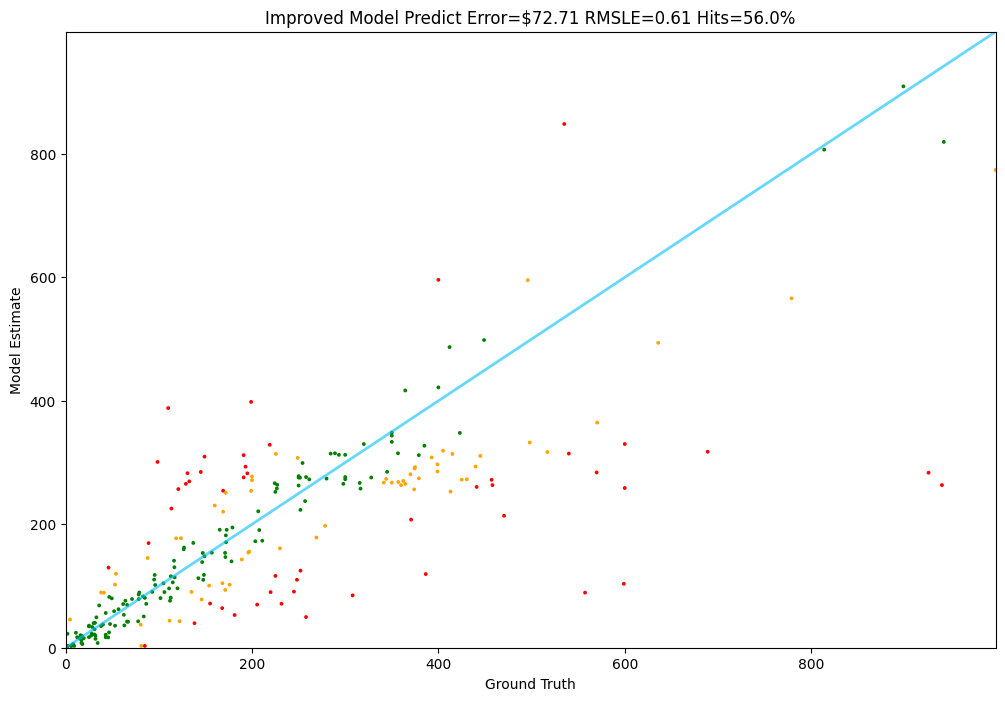

In [22]:
print("==> test: {}, {}".format(datetime.now().astimezone().strftime("%FT%T%:z"), FINETUNED_MODEL))

Tester.test(improved_model_predict, test)
# epoch, steps,     error,   rmsle, hits
# a1,    100_000,   115.31,  0.88,  40.0%
# a2,    28_000,    82.48,   0.72,  49.6%
# a2,    30_000,    83.04,   0.68,  49.2%
# a2,    32_000,    80.17,   0.66,  48.4%
# a2,    36_000,    80.76,   0.62,  48.4%
# a2,    38_000,    80.52,   0.67,  49.6%
# a2,    78_000,    71.85,   0.59,  56.0%
# a2,    84_000,    72.03,   0.62,  54.2%
# a2,    98_000,    73.48,   0.62,  54.0%
# a2,    100_000,   73.51,   0.62,  54.8%
# b1,    102_000,   75.51,   0.63,  54.4%
# b1,    104_000,   81.11,   0.65,  50.4%
# b1-e,  unknown,   72.71,   0.61,  56.0%